In [1]:
# Cross-Species Accessibility Heatmap
# Blocked heatmap of evolutionary peak categories for a single cell type.
# Each block = a set of peaks gained/upregulated on a specific primate lineage.
# Values = mean log2(CPM + 1) or row z-score (toggle below).
# Gray cells = no orthologous sequence in that species.

In [2]:
import pandas as pd
import numpy as np
import os, glob, math
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib.patches import Patch

# ── Paths ──────────────────────────────────────────────────────────────────────
BASE       = "/cluster/project/treutlein/USERS/jjans/analysis/adult_intestine/peaks"
CONS_DIR   = f"{BASE}/cross_species_consensus_v3"
DESEQ_DIR  = f"{CONS_DIR}/13_deseq2_R_pseudobulk"
ANNO_PATH  = f"{CONS_DIR}/07_master_annotation/master_annotation_corrected.tsv"
FRAG_DIR   = f"{CONS_DIR}/12_fragment_matrices"
ROBUST_DIR = f"{DESEQ_DIR}/differential_results/ultra_robust_branches"
BRANCH_DIR = f"{DESEQ_DIR}/differential_results/evolutionary_branches"

SPECIES    = ["Human", "Bonobo", "Chimpanzee", "Gorilla", "Macaque", "Marmoset"]
CELL_TYPE  = "Enterocytes"
MAX_PER_BLOCK = 50

# ── Heatmap mode toggles ───────────────────────────────────────────────────────
# ACCESSIBILITY_VIEW:
#   "species" -> one column per species (mean across donor pseudobulks)
#   "donor"   -> donor-resolved columns
# DONOR_SPLIT_BY (used only when ACCESSIBILITY_VIEW == "donor"):
#   "donor"         -> Species|Donor
#   "donor_region"  -> Species|Donor|Region
ACCESSIBILITY_VIEW = "donor"
DONOR_SPLIT_BY = "donor"
ROW_ZSCORE = False

# ── Load corrected annotation ─────────────────────────────────────────────────
print("Loading annotation...")
anno = pd.read_csv(ANNO_PATH, sep="\t", low_memory=False).set_index("peak_id")
orth_cols = {sp: f"{sp}_orth" for sp in SPECIES}
det_cols  = {sp: f"{sp}_det"  for sp in SPECIES}
print(f"  {anno.shape[0]:,} peaks × {anno.shape[1]} columns")

/cluster/project/treutlein/jjans/software/miniforge3/envs/scenicplus/lib/python3.11/site-packages/pandas/core/computation/expressions.py:22: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.9.0' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED


Loading annotation...
  1,142,003 peaks × 59 columns


In [3]:
# ── Load pseudobulk counts for Enterocytes ────────────────────────────────────
# Builds three matrices:
#   1) species-level: mean log2(CPM+1) per species
#   2) donor-level:   mean log2(CPM+1) per donor (Species|Donor)
#   3) donor-region:  mean log2(CPM+1) per donor-region (Species|Donor|Region)

acc_species = {}
acc_donor = {}
acc_donor_region = {}

for sp in SPECIES:
    counts_path = f"{FRAG_DIR}/{sp}/pseudobulk_counts.parquet"
    groups_path = f"{FRAG_DIR}/{sp}/pseudobulk_groups.parquet"
    if not os.path.exists(counts_path):
        print(f"  {sp}: counts parquet missing, trying tsv...")
        counts_path = counts_path.replace(".parquet", ".tsv")
        groups_path = groups_path.replace(".parquet", ".tsv")

    if groups_path.endswith(".parquet"):
        groups = pd.read_parquet(groups_path)
    else:
        groups = pd.read_csv(groups_path, sep="\t")

    ct_groups = groups[groups["cell_type"] == CELL_TYPE].copy()
    if len(ct_groups) == 0:
        print(f"  {sp}: no {CELL_TYPE} samples, skipping")
        continue

    labels = ct_groups["label"].tolist()
    print(f"  {sp}: {len(labels)} {CELL_TYPE} pseudobulks ({ct_groups['n_cells'].sum()} cells)")

    if counts_path.endswith(".parquet"):
        df = pd.read_parquet(counts_path)
        if "region_id" in df.columns:
            df = df.set_index("region_id")
    else:
        df = pd.read_csv(counts_path, sep="\t", index_col=0)

    valid_labels = [l for l in labels if l in df.columns]
    if len(valid_labels) == 0:
        print(f"  {sp}: no matching count columns after label filtering")
        continue
    sub = df[valid_labels]

    # Species-level accessibility (mean counts across all pseudobulks in species)
    mean_counts_species = sub.mean(axis=1)
    total_species = mean_counts_species.sum()
    cpm_species = (mean_counts_species / total_species * 1e6) if total_species > 0 else mean_counts_species
    acc_species[sp] = np.log2(cpm_species + 1)

    # Build metadata lookup per label
    meta_lookup = ct_groups.set_index("label")[["donor", "region"]].astype(str)

    # Donor-level accessibility
    donor_to_labels = {}
    for lbl in valid_labels:
        donor = meta_lookup.at[lbl, "donor"] if lbl in meta_lookup.index else "Unknown"
        donor_to_labels.setdefault(donor, []).append(lbl)

    for donor, donor_labels in donor_to_labels.items():
        donor_counts = sub[donor_labels].mean(axis=1)
        donor_total = donor_counts.sum()
        donor_cpm = (donor_counts / donor_total * 1e6) if donor_total > 0 else donor_counts
        acc_donor[f"{sp}|{donor}"] = np.log2(donor_cpm + 1)

    # Donor-region-level accessibility
    donor_region_to_labels = {}
    for lbl in valid_labels:
        if lbl in meta_lookup.index:
            donor = meta_lookup.at[lbl, "donor"]
            region = meta_lookup.at[lbl, "region"]
        else:
            donor, region = "Unknown", "Unknown"
        key = f"{donor}|{region}"
        donor_region_to_labels.setdefault(key, []).append(lbl)

    for key, key_labels in donor_region_to_labels.items():
        dr_counts = sub[key_labels].mean(axis=1)
        dr_total = dr_counts.sum()
        dr_cpm = (dr_counts / dr_total * 1e6) if dr_total > 0 else dr_counts
        acc_donor_region[f"{sp}|{key}"] = np.log2(dr_cpm + 1)

acc_species_df = pd.DataFrame(acc_species)
acc_donor_df = pd.DataFrame(acc_donor)
acc_donor_region_df = pd.DataFrame(acc_donor_region)

if ACCESSIBILITY_VIEW == "species":
    acc_df = acc_species_df
elif ACCESSIBILITY_VIEW == "donor":
    if DONOR_SPLIT_BY == "donor":
        acc_df = acc_donor_df
    elif DONOR_SPLIT_BY == "donor_region":
        acc_df = acc_donor_region_df
    else:
        raise ValueError("DONOR_SPLIT_BY must be 'donor' or 'donor_region'")
else:
    raise ValueError("ACCESSIBILITY_VIEW must be 'species' or 'donor'")

print(f"\nSpecies matrix:      {acc_species_df.shape[0]:,} peaks × {acc_species_df.shape[1]} columns")
print(f"Donor matrix:        {acc_donor_df.shape[0]:,} peaks × {acc_donor_df.shape[1]} columns")
print(f"Donor-region matrix: {acc_donor_region_df.shape[0]:,} peaks × {acc_donor_region_df.shape[1]} columns")
print(f"Selected ({ACCESSIBILITY_VIEW}/{DONOR_SPLIT_BY}): {acc_df.shape[0]:,} peaks × {acc_df.shape[1]} columns")

  Human: 5 Enterocytes pseudobulks (4466 cells)
  Bonobo: 2 Enterocytes pseudobulks (1901 cells)
  Chimpanzee: 3 Enterocytes pseudobulks (1613 cells)
  Gorilla: 3 Enterocytes pseudobulks (439 cells)
  Macaque: 1 Enterocytes pseudobulks (1062 cells)
  Marmoset: 2 Enterocytes pseudobulks (6101 cells)

Species matrix:      1,142,003 peaks × 6 columns
Donor matrix:        1,142,003 peaks × 16 columns
Donor-region matrix: 1,142,003 peaks × 16 columns
Selected (species/donor): 1,142,003 peaks × 6 columns


In [8]:
# ── Helper functions ───────────────────────────────────────────────────────────

def is_true(series):
    """Coerce mixed bool/str/int column to boolean mask."""
    if series.dtype == bool:
        return series.fillna(False)
    if series.dtype == object:
        return series.astype(str).str.strip().str.upper().isin(["TRUE", "1"])
    return series.fillna(0).astype(bool)

def load_robust(contrast):
    """Load ultra-robust peak IDs for CELL_TYPE."""
    path = f"{ROBUST_DIR}/{CELL_TYPE}/{contrast}_UltraRobust.csv"
    if not os.path.exists(path):
        print(f"  [MISSING robust] {contrast}")
        return set()
    return set(pd.read_csv(path).iloc[:, 0].astype(str))

def load_branch_df(contrast):
    """Load full DESeq2 branch result for CELL_TYPE."""
    path = f"{BRANCH_DIR}/{CELL_TYPE}/{contrast}.csv"
    if not os.path.exists(path):
        return None
    df = pd.read_csv(path)
    id_col = "peak_id" if "peak_id" in df.columns else df.columns[0]
    df = df.set_index(id_col)
    return df

def load_branch_sig(contrast, padj=0.05, lfc=1.0):
    """Load significant UP peak IDs from branch result."""
    df = load_branch_df(contrast)
    if df is None:
        print(f"  [MISSING branch] {contrast}")
        return set()
    df = df.dropna(subset=["padj", "log2FoldChange"])
    sig = df[(df["padj"] < padj) & (df["log2FoldChange"] > lfc)]
    return set(sig.index.astype(str))

def ortho_filter(peaks, required_species):
    """Keep only peaks with orthologous sequence in ALL required species."""
    mask = anno[[orth_cols[s] for s in required_species]].apply(
        lambda c: is_true(c)).all(axis=1)
    return set(peaks) & set(anno.index[mask])

def rank_peaks(peak_set, contrast, n=MAX_PER_BLOCK):
    """Rank peaks by |LFC| × −log10(padj) from branch result, return top n."""
    df = load_branch_df(contrast)
    if df is None:
        return list(peak_set)[:n]
    df = df.loc[df.index.intersection(peak_set)].dropna(subset=["padj", "log2FoldChange"])
    df["score"] = df["log2FoldChange"].abs() * (-np.log10(df["padj"].clip(lower=1e-300)))
    return list(df.sort_values("score", ascending=False).head(n).index)

def rank_by_basemean(peak_set, n=MAX_PER_BLOCK):
    """Rank peaks by baseMean from any available branch contrast."""
    for contrast in ["Div_Human_vs_Apes", "Node1_Human_vs_Pan"]:
        df = load_branch_df(contrast)
        if df is not None:
            overlap = df.index.intersection(peak_set)
            if len(overlap) > 0:
                return list(df.loc[overlap].sort_values("baseMean", ascending=False).head(n).index)
    if "Human" in acc_df.columns:
        overlap = acc_df.index.intersection(peak_set)
        return list(acc_df.loc[overlap, "Human"].sort_values(ascending=False).head(n).index)
    return list(peak_set)[:n]

def acc_waterfall(peak_set, up_species, down_species):
    """
    Strict waterfall: for each peak, the MAX accessibility among down-species
    (that have orthology) must be below the MIN of up-species.
    This guarantees a clean step in every single peak.
    """
    peaks = sorted(set(peak_set) & set(acc_df.index))
    if not peaks:
        return set()

    sub = acc_df.loc[peaks]
    up_min = sub[up_species].min(axis=1)

    keep = pd.Series(True, index=peaks)
    for sp in down_species:
        has_orth = is_true(anno.reindex(peaks)[orth_cols[sp]])
        sp_val = sub[sp].fillna(-999)  # no data → always passes
        # Fail if species has ortholog AND its value >= min of up-species
        keep &= ~(has_orth & (sp_val >= up_min))

    return set(pd.Index(peaks)[keep])

def posthoc_filter(peak_list, up_species, down_species):
    """
    Post-hoc filter on the accessibility matrix: remove any remaining peaks
    where a down-species (with orthology) has accessibility within 80% of
    the up-species mean. Returns filtered ordered list.
    """
    if not peak_list:
        return peak_list
    peaks = [p for p in peak_list if p in acc_df.index]
    sub = acc_df.loc[peaks]
    up_mean = sub[up_species].mean(axis=1)

    keep = pd.Series(True, index=peaks)
    for sp in down_species:
        has_orth = is_true(anno.reindex(peaks)[orth_cols[sp]])
        sp_val = sub[sp].fillna(0)
        # Reject if down-species value > 80% of up-species mean
        keep &= ~(has_orth & (sp_val > up_mean * 0.8))

    return [p for p in peaks if keep[p]]

print("Helpers loaded.")

Helpers loaded.


In [9]:
# ── Build regions dictionary (strict evolutionary waterfall) ──────────────────

other_sp = [s for s in SPECIES if s != "Human"]
regions = {}

# ── Pre-load ultra-robust sets ────────────────────────────────────────────────
robust = {}
for c in ["Node4_OldWorld_vs_Marmoset", "Node3_GreatApes_vs_Macaque",
          "ILS_HumanGorilla_vs_Pan", "ILS_HumanChimp_vs_GorillaBonobo",
          "ILS_HumanBonobo_vs_ChimpGorilla", "Div_Human_vs_Apes",
          "Node1_Human_vs_Pan"]:
    robust[c] = load_robust(c)

# ── Pre-load significant peaks for hierarchical subtraction ──────────────────
sig_node4 = load_branch_sig("Node4_OldWorld_vs_Marmoset", padj=0.1, lfc=0.5)
sig_node3 = load_branch_sig("Node3_GreatApes_vs_Macaque", padj=0.1, lfc=0.5)
deeper_than_ils = (robust["Node3_GreatApes_vs_Macaque"] |
                   robust["Node4_OldWorld_vs_Marmoset"] |
                   sig_node3 | sig_node4)
deeper_than_n3  = (robust["Node4_OldWorld_vs_Marmoset"] | sig_node4)

# ── 1. Human-Specific DNA ────────────────────────────────────────────────────
human_spec_mask = (
    is_true(anno[orth_cols["Human"]]) &
    anno[[orth_cols[s] for s in other_sp]].apply(lambda c: ~is_true(c)).all(axis=1) &
    is_true(anno[det_cols["Human"]])
)
human_spec_all = set(anno.index[human_spec_mask])
regions["Human-specific DNA"] = rank_by_basemean(human_spec_all)
print(f"  Human-specific DNA:           {len(human_spec_all):>5} → {len(regions['Human-specific DNA'])} shown")

# ── 2–4. ILS contrasts ───────────────────────────────────────────────────────
ils_defs = [
    ("ILS: Human + Gorilla UP",  "ILS_HumanGorilla_vs_Pan",
     ["Human", "Gorilla"],       ["Chimpanzee", "Bonobo"]),
    ("ILS: Human + Chimp UP",    "ILS_HumanChimp_vs_GorillaBonobo",
     ["Human", "Chimpanzee"],    ["Gorilla", "Bonobo"]),
    ("ILS: Human + Bonobo UP",   "ILS_HumanBonobo_vs_ChimpGorilla",
     ["Human", "Bonobo"],        ["Chimpanzee", "Gorilla"]),
]
for label, contrast, up_sp, contrast_down_sp in ils_defs:
    filtered = ortho_filter(robust[contrast], up_sp + contrast_down_sp)
    filtered -= deeper_than_ils
    all_down = contrast_down_sp + ["Macaque", "Marmoset"]
    filtered = acc_waterfall(filtered, up_sp, all_down)
    ranked = rank_peaks(filtered, contrast)
    ranked = posthoc_filter(ranked, up_sp, all_down)
    regions[label] = ranked
    print(f"  {label}:  {len(filtered):>5} → {len(regions[label])} shown")

# ── 5. Great Apes UP vs Macaque ───────────────────────────────────────────────
n3_filtered = ortho_filter(
    robust["Node3_GreatApes_vs_Macaque"],
    ["Human", "Chimpanzee", "Bonobo", "Gorilla", "Macaque"]
)
n3_filtered -= deeper_than_n3
n3_filtered = acc_waterfall(
    n3_filtered,
    ["Human", "Chimpanzee", "Bonobo", "Gorilla"],
    ["Macaque", "Marmoset"]
)
ranked = rank_peaks(n3_filtered, "Node3_GreatApes_vs_Macaque")
ranked = posthoc_filter(ranked, ["Human", "Chimpanzee", "Bonobo", "Gorilla"], ["Macaque", "Marmoset"])
regions["Great Apes UP vs Macaque"] = ranked
print(f"  Great Apes UP vs Macaque:     {len(n3_filtered):>5} → {len(regions['Great Apes UP vs Macaque'])} shown")

# ── 6. Old World UP vs Marmoset ──────────────────────────────────────────────
n4_filtered = ortho_filter(robust["Node4_OldWorld_vs_Marmoset"], SPECIES)
n4_filtered = acc_waterfall(
    n4_filtered,
    ["Human", "Chimpanzee", "Bonobo", "Gorilla", "Macaque"],
    ["Marmoset"]
)
ranked = rank_peaks(n4_filtered, "Node4_OldWorld_vs_Marmoset")
ranked = posthoc_filter(ranked, ["Human", "Chimpanzee", "Bonobo", "Gorilla", "Macaque"], ["Marmoset"])
regions["Old World UP vs Marmoset"] = ranked
print(f"  Old World UP vs Marmoset:     {len(n4_filtered):>5} → {len(regions['Old World UP vs Marmoset'])} shown")

# ── Summary ───────────────────────────────────────────────────────────────────
print(f"\n{'='*55}")
all_shown = set()
for label, peaks in regions.items():
    print(f"  {label:<35} {len(peaks):>5}")
    all_shown |= set(peaks)
print(f"  {'─'*49}")
print(f"  {'Total unique peaks shown':<35} {len(all_shown):>5}")

  Human-specific DNA:            1594 → 50 shown
  ILS: Human + Gorilla UP:   1776 → 20 shown
  ILS: Human + Chimp UP:    354 → 35 shown
  ILS: Human + Bonobo UP:    328 → 39 shown
  Great Apes UP vs Macaque:       907 → 39 shown
  Old World UP vs Marmoset:      4685 → 50 shown

  Human-specific DNA                     50
  ILS: Human + Gorilla UP                20
  ILS: Human + Chimp UP                  35
  ILS: Human + Bonobo UP                 39
  Great Apes UP vs Macaque               39
  Old World UP vs Marmoset               50
  ─────────────────────────────────────────────────
  Total unique peaks shown              233


In [10]:
# ── Build heatmap matrix ───────────────────────────────────────────────────────
# Concatenate peaks in category order, enforce NaN where _orth=False

ordered_peaks = []
block_labels = []
block_sizes = []

for label, peaks in regions.items():
    ordered_peaks.extend(peaks)
    block_labels.append(label)
    block_sizes.append(len(peaks))

# Subset accessibility to our peaks (keeps order)
heatmap_df = acc_df.reindex(ordered_peaks)[SPECIES]

# Enforce NaN where species has no orthologous sequence
for sp in SPECIES:
    orth_mask = is_true(anno.reindex(ordered_peaks)[orth_cols[sp]])
    heatmap_df.loc[~orth_mask.values, sp] = np.nan

print(f"Heatmap matrix: {heatmap_df.shape[0]} peaks × {heatmap_df.shape[1]} species")
print(f"Blocks: {dict(zip(block_labels, block_sizes))}")
print(f"NaN cells (no ortholog): {heatmap_df.isna().sum().sum():.0f}")

Heatmap matrix: 233 peaks × 6 species
Blocks: {'Human-specific DNA': 50, 'ILS: Human + Gorilla UP': 20, 'ILS: Human + Chimp UP': 35, 'ILS: Human + Bonobo UP': 39, 'Great Apes UP vs Macaque': 39, 'Old World UP vs Marmoset': 50}
NaN cells (no ortholog): 291


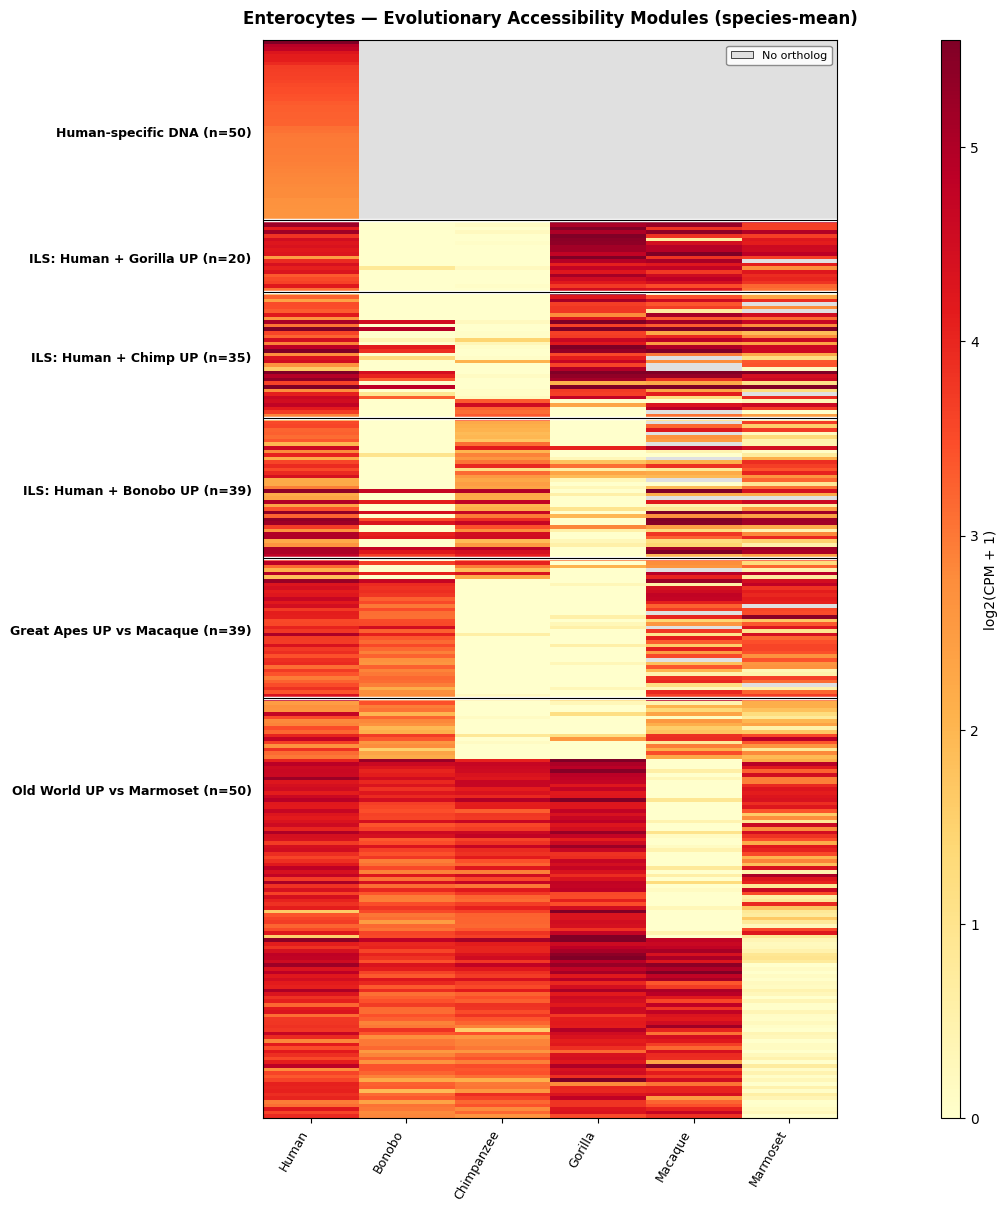


Saved to /cluster/project/treutlein/USERS/jjans/analysis/adult_intestine/peaks/cross_species_consensus_v3/13_deseq2_R_pseudobulk/Enterocytes_evolutionary_heatmap.pdf


In [11]:
# ── Plot blocked heatmap ───────────────────────────────────────────────────────

n_peaks = heatmap_plot_df.shape[0]
fig_h = max(6, n_peaks * 0.04 + 2)
fig, (ax, cax) = plt.subplots(
    1, 2, figsize=(9, fig_h),
    gridspec_kw={"width_ratios": [30, 1], "wspace": 0.35}
)

# Colormap with gray for NaN cells (no ortholog)
if ROW_ZSCORE:
    cmap = plt.cm.RdBu_r.copy()
else:
    cmap = plt.cm.YlOrRd.copy()
cmap.set_bad(color="#e0e0e0")

data = heatmap_plot_df.values.astype(float)

if ROW_ZSCORE:
    abs_max = np.nanpercentile(np.abs(data[~np.isnan(data)]), 98)
    abs_max = max(abs_max, 1e-6)
    norm = mcolors.TwoSlopeNorm(vmin=-abs_max, vcenter=0.0, vmax=abs_max)
    im = ax.imshow(data, aspect="auto", cmap=cmap, norm=norm, interpolation="nearest")
else:
    vmin, vmax = np.nanpercentile(data[~np.isnan(data)], [2, 98])
    im = ax.imshow(data, aspect="auto", cmap=cmap, vmin=vmin, vmax=vmax, interpolation="nearest")

# X axis
ax.set_xticks(range(len(heatmap_plot_df.columns)))
ax.set_xticklabels(list(heatmap_plot_df.columns), rotation=60, ha="right", fontsize=9)
ax.xaxis.set_ticks_position("bottom")

# Block separators and labels
cum = 0
label_positions = []
for i, (label, size) in enumerate(zip(block_labels, block_sizes)):
    if i > 0:
        ax.axhline(cum - 0.5, color="white", linewidth=2.5)
        ax.axhline(cum - 0.5, color="black", linewidth=0.8)
    label_positions.append(cum + size / 2)
    cum += size

ax.set_yticks(label_positions)
ax.set_yticklabels([f"{l} (n={s})" for l, s in zip(block_labels, block_sizes)],
                   fontsize=9, fontweight="bold")
ax.tick_params(axis="y", length=0, pad=8)

# Dedicated colorbar axis on the side (no overlap)
cb = fig.colorbar(im, cax=cax)
cb.set_label("Row z-score" if ROW_ZSCORE else "log2(CPM + 1)", fontsize=10)

# Legend for gray cells
legend_elements = [Patch(facecolor="#e0e0e0", edgecolor="black", linewidth=0.5,
                         label="No ortholog")]
ax.legend(handles=legend_elements, loc="upper right", fontsize=8,
          framealpha=0.9, edgecolor="gray")

if ACCESSIBILITY_VIEW == "species":
    title_mode = "species-mean"
else:
    title_mode = "donor" if DONOR_SPLIT_BY == "donor" else "donor+region"

ax.set_title(
    f"{CELL_TYPE} — Evolutionary Accessibility Modules ({title_mode})",
    fontsize=12, fontweight="bold", pad=12
)

plt.savefig(f"{DESEQ_DIR}/{CELL_TYPE}_evolutionary_heatmap.pdf",
            bbox_inches="tight", dpi=150)
plt.savefig(f"{DESEQ_DIR}/{CELL_TYPE}_evolutionary_heatmap.png",
            bbox_inches="tight", dpi=150)
plt.show()
print(f"\nSaved to {DESEQ_DIR}/{CELL_TYPE}_evolutionary_heatmap.pdf")